# Lab 02 · Parte 1 — Teoría de conjuntos con plantillas de fútbol (R)

Disponemos de **40 archivos CSV**: las plantillas de las últimas **20 temporadas** (2004-05 a 2023-24) de dos clubes.

| Conjunto | Club | Archivos |
|---|---|---|
| **A** | Atlético de Madrid | `atletico_AAAA-AA.csv` |
| **B** | FC Barcelona | `barcelona_AAAA-AA.csv` |

Cada archivo tiene una única columna, `jugador`. Un jugador que estuvo varias temporadas aparece en varios archivos, así que primero hay que **eliminar duplicados** para que cada club sea un conjunto en sentido matemático: cada elemento aparece una sola vez.

## Preparación

Los CSV están montados en el contenedor en `/home/jovyan/datasets`. Si el notebook se ejecuta fuera de Docker, se usa la ruta relativa del repositorio.

In [1]:
library(ggplot2)

data_dir <- "/home/jovyan/datasets/lab02/futbol_data"
if (!dir.exists(data_dir)) data_dir <- "../../datasets/lab02/futbol_data"

cat(normalizePath(data_dir), "->", length(list.files(data_dir, pattern = "\\.csv$")), "archivos CSV\n")

/home/jovyan/datasets/lab02/futbol_data -> 40 archivos CSV


## Parte 1. Construcción de los conjuntos

### 1–3. Leer los 20 archivos de cada club y eliminar duplicados

`list.files()` con un patrón encuentra automáticamente los archivos de cada club. Se leen con `fileEncoding = "UTF-8-BOM"` para que la cabecera no se lea como `X.U.FEFF.jugador`. En R un conjunto es un vector sin repetidos: `unique()` elimina los duplicados.

In [2]:
leer_club <- function(prefijo) {
  archivos <- list.files(data_dir, pattern = paste0("^", prefijo, "_.*\\.csv$"), full.names = TRUE)
  stopifnot(length(archivos) == 20)
  plantillas <- do.call(rbind, lapply(archivos, read.csv, fileEncoding = "UTF-8-BOM"))
  jugadores <- trimws(plantillas$jugador)
  list(filas = length(jugadores), conjunto = unique(jugadores))
}

atletico  <- leer_club("atletico")    # Club A
barcelona <- leer_club("barcelona")   # Club B
club_a <- atletico$conjunto
club_b <- barcelona$conjunto

cat(sprintf("Atlético : %d filas -> %d jugadores únicos\n", atletico$filas, length(club_a)))
cat(sprintf("Barcelona: %d filas -> %d jugadores únicos\n", barcelona$filas, length(club_b)))

Atlético : 264 filas -> 58 jugadores únicos
Barcelona: 287 filas -> 53 jugadores únicos


### 4. ¿Cuántos jugadores únicos ha tenido cada club?

### 5. Conjuntos ordenados alfabéticamente

A diferencia de Python, `sort()` en R ordena según la configuración regional (`en_US.UTF-8`), así que los nombres con tilde ya quedan en su sitio alfabético.

In [3]:
data.frame(Club = c("Atlético (A)", "Barcelona (B)"),
           Jugadores_unicos = c(length(club_a), length(club_b)))

Club,Jugadores_unicos
<chr>,<int>
Atlético (A),58
Barcelona (B),53


In [4]:
cat(sprintf("Club A — Atlético (%d jugadores)\n\n", length(club_a)))
cat(paste(sort(club_a), collapse = ", "), "\n")

Club A — Atlético (58 jugadores)

Adrián López, Álvaro Domínguez, Álvaro Morata, Ángel Correa, Antoine Griezmann, Antonio López, Arda Turan, Axel Witsel, César Azpilicueta, Colsa, David de Gea, David Villa, Diego Forlán, Diego Godín, Fernando Torres, Filipe Luís, García Calvo, Giménez, Grzegorz Rasiak, Ibagaza, Jan Oblak, João Félix, John Heitinga, Jorge Larena, José Manuel Jurado, Juan Valera, Juan Velasco, Juanfran Torres, Koke Resurrección, Leo Franco, Luis Perea, Marco Babić, Marcos Llorente, Mario Suárez, Matheus Cunha, Maxi Rodríguez, Memphis Depay, Miranda, Nahuel Molina, Oliver Torres, Pablo Ibáñez, Paulo Assunção, Peter Luccin, Raúl García, Renan Lodi, Richard Núñez, Rodrigo de Paul, Salva Ballesta, Saúl Ñíguez, Sergi Barjuán, Sergio Agüero, Simão Sabrosa, Stefan Savić, Thiago Motta, Thibaut Courtois, Thomas Partey, Tiago Mendes, Yannick Carrasco 


In [5]:
cat(sprintf("Club B — Barcelona (%d jugadores)\n\n", length(club_b)))
cat(paste(sort(club_b), collapse = ", "), "\n")

Club B — Barcelona (53 jugadores)

Albert Jorquera, Alexis Sánchez, Andrés Iniesta, Ansu Fati, Antoine Griezmann, Carles Puyol, Cesc Fàbregas, Dani Alves, David Villa, Deco, Edmilson, Éric Abidal, Fernando Navarro, Ferran Torres, Frenkie de Jong, Gabriel Milito, Gavi, Gerard Piqué, Giovanni van Bronckhorst, Henrik Larsson, İlkay Gündoğan, Ivan Rakitic, Javier Mascherano, João Cancelo, João Félix, Jordi Alba, Jules Koundé, Juliano Belletti, Lamine Yamal, Lionel Messi, Ludovic Giuly, Luis Suárez, Marc-André ter Stegen, Neymar Jr, Oleguer Presas, Ousmane Dembélé, Pedri, Pedro Rodríguez, Rafa Márquez, Raphinha, Robert Lewandowski, Ronald Araújo, Ronaldinho, Samuel Eto'o, Samuel Umtiti, Sergio Busquets, Seydou Keita, Sylvinho, Thierry Henry, Víctor Valdés, Xavi Hernández, Yaya Touré, Zlatan Ibrahimović 


## Parte 2. Operaciones con conjuntos

### 1. Unión $A \cup B$: jugadores que han pasado por alguno de los dos clubes

In [6]:
union_ab <- union(club_a, club_b)
universo <- union_ab
cat("Jugadores diferentes en alguno de los dos clubes:", length(union_ab), "\n")

Jugadores diferentes en alguno de los dos clubes: 108 


### 2. Intersección $A \cap B$: jugadores que han estado en ambos clubes

In [7]:
interseccion <- intersect(club_a, club_b)
cat(length(interseccion), "jugadores en ambos clubes:\n")
cat(paste(" -", sort(interseccion)), sep = "\n")

3 jugadores en ambos clubes:
 - Antoine Griezmann
 - David Villa
 - João Félix


### 3. Diferencia $A \setminus B$: jugadores que solo han jugado en el Atlético

In [8]:
solo_a <- setdiff(club_a, club_b)
cat(length(solo_a), "jugadores solo en el Atlético:\n\n")
cat(paste(sort(solo_a), collapse = ", "), "\n")

55 jugadores solo en el Atlético:

Adrián López, Álvaro Domínguez, Álvaro Morata, Ángel Correa, Antonio López, Arda Turan, Axel Witsel, César Azpilicueta, Colsa, David de Gea, Diego Forlán, Diego Godín, Fernando Torres, Filipe Luís, García Calvo, Giménez, Grzegorz Rasiak, Ibagaza, Jan Oblak, John Heitinga, Jorge Larena, José Manuel Jurado, Juan Valera, Juan Velasco, Juanfran Torres, Koke Resurrección, Leo Franco, Luis Perea, Marco Babić, Marcos Llorente, Mario Suárez, Matheus Cunha, Maxi Rodríguez, Memphis Depay, Miranda, Nahuel Molina, Oliver Torres, Pablo Ibáñez, Paulo Assunção, Peter Luccin, Raúl García, Renan Lodi, Richard Núñez, Rodrigo de Paul, Salva Ballesta, Saúl Ñíguez, Sergi Barjuán, Sergio Agüero, Simão Sabrosa, Stefan Savić, Thiago Motta, Thibaut Courtois, Thomas Partey, Tiago Mendes, Yannick Carrasco 


### 4. Diferencia simétrica $A \triangle B$: jugadores que han jugado en uno solo de los dos clubes

R base no tiene una función de diferencia simétrica: se construye como $(A \setminus B) \cup (B \setminus A)$.

In [9]:
solo_b <- setdiff(club_b, club_a)
diferencia_simetrica <- union(solo_a, solo_b)
cat(sprintf("%d jugadores exclusivos de un único club (%d del Atlético + %d del Barcelona)\n",
            length(diferencia_simetrica), length(solo_a), length(solo_b)))

105 jugadores exclusivos de un único club (55 del Atlético + 50 del Barcelona)


### 5. Complemento de la intersección respecto al universo $U = A \cup B$

$(A \cap B)^c = U \setminus (A \cap B)$: jugadores que **no** han pasado por ambos clubes.

In [10]:
complemento_interseccion <- setdiff(universo, interseccion)
cat(length(complemento_interseccion), "jugadores no han pasado por ambos clubes\n")
cat("¿Coincide con la diferencia simétrica?", setequal(complemento_interseccion, diferencia_simetrica), "\n")

105 jugadores no han pasado por ambos clubes
¿Coincide con la diferencia simétrica? TRUE 


## Parte 3. Análisis de resultados

In [11]:
porcentaje_ambos <- length(interseccion) / length(universo) * 100
cat(sprintf("1. Han jugado en ambos clubes: %d de %d = %.2f %% del universo\n",
            length(interseccion), length(universo), porcentaje_ambos))

exclusivos <- c("Atlético" = length(solo_a), "Barcelona" = length(solo_b))
cat(sprintf("2. Jugadores exclusivos: Atlético %d, Barcelona %d -> más exclusivos: %s\n",
            exclusivos[["Atlético"]], exclusivos[["Barcelona"]], names(which.max(exclusivos))))

# Comprobación del principio de inclusión-exclusión
stopifnot(length(union_ab) == length(club_a) + length(club_b) - length(interseccion))

1. Han jugado en ambos clubes: 3 de 108 = 2.78 % del universo
2. Jugadores exclusivos: Atlético 55, Barcelona 50 -> más exclusivos: Atlético


## Parte 4. Ampliación: diagrama de Venn

La imagen no incluye `VennDiagram` ni `ggVennDiagram`, así que el diagrama se dibuja con `ggplot2` calculando los puntos de cada círculo.

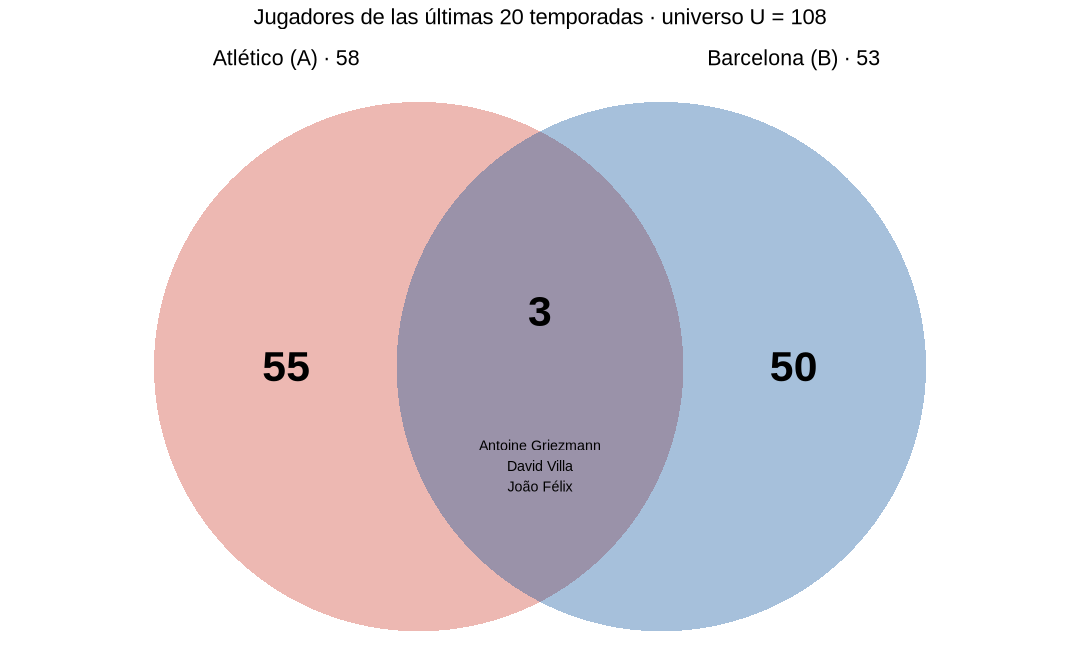

In [12]:
options(repr.plot.width = 9, repr.plot.height = 5.5)

circulo <- function(cx, club, r = 1.2, n = 200) {
  t <- seq(0, 2 * pi, length.out = n)
  data.frame(x = cx + r * cos(t), y = r * sin(t), club = club)
}
circulos <- rbind(circulo(-0.55, "Atlético (A)"), circulo(0.55, "Barcelona (B)"))

ggplot(circulos, aes(x, y, fill = club)) +
  geom_polygon(alpha = 0.35) +
  annotate("text", x = c(-1.15, 1.15, 0), y = c(0, 0, 0.25),
           label = c(length(solo_a), length(solo_b), length(interseccion)),
           size = 9, fontface = "bold") +
  annotate("text", x = 0, y = -0.45, label = paste(sort(interseccion), collapse = "\n"), size = 3) +
  annotate("text", x = c(-1.15, 1.15), y = 1.4,
           label = c(sprintf("Atlético (A) · %d", length(club_a)),
                     sprintf("Barcelona (B) · %d", length(club_b))), size = 4.5) +
  scale_fill_manual(values = c("#CB3524", "#004D98"), guide = "none") +
  coord_equal() +
  labs(title = sprintf("Jugadores de las últimas 20 temporadas · universo U = %d", length(universo))) +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5))

## Conclusiones

- Por el **Atlético** han pasado **58** jugadores distintos y por el **Barcelona**, **53**.
- El universo (unión) tiene **108** jugadores, y solo **3** han jugado en ambos clubes: Antoine Griezmann, David Villa y João Félix. Son el **2,78 %** del universo.
- El Atlético tiene más jugadores exclusivos (**55** frente a **50**).
- El complemento de la intersección dentro del universo coincide con la **diferencia simétrica** (105 jugadores): $U \setminus (A \cap B) = A \triangle B$ cuando $U = A \cup B$.
- Comprobación de cardinales: $|A \cup B| = |A| + |B| - |A \cap B| = 58 + 53 - 3 = 108$.